# Introduction


**File:** Notebook_Slow_k_IVP.ipynb 
\
**Author:** Elizabeth Gould
\
**Date:** 10.03.2026
\
**Problem:** Find $M_{\mu}\left(BR, dk, \mu, \psi_0^\prime\right)$

This is my Jupyter notebook for finding a model for the parameter dependence of the wave number of the slow oscillations of the solution to the IVP of the nonlinear Schrödinger equation for persistent current in a single micrometer scale gold loop ($M_{\mu}$). 

Our nonlinear time-independent Schrödinger equation is
\begin{equation}
H \psi = k^2 \psi = \left( i \frac{d}{dx} + \frac{\pi BR}{\Phi_0} \right)^2 \psi + \mu \frac{m_e}{\left|e\right|\hbar} \left|\psi\right|^2 \psi.
\end{equation}
Our observed approximate solution to the nonlinear Schrödinger equation is
\begin{equation}
\psi = e^{i M_{\mu} x} \left( a e^{i k_{\mu} x} + b e^{- i k_{\mu} x} \right),
\end{equation}
where $k_{\mu}$ and $M_{\mu}$ differ from the case of the linear Schrödinger equation, which has a solution of
\begin{equation}
\psi = e^{i M_0 x} \left( a e^{i k_0 x} + b e^{- i k_0 x} \right),
\end{equation}
with $M_{0}$ = $\frac{\pi BR}{\Phi_0}$, and $k_{0}$ = $k0 + \frac{dk}{2  R_{max} }$. This notebook calculates how $M_{\mu}$ depends on $B * R$, $dk$, $\mu$, and $\psi^\prime_0$. $k$ dependencies are not given, since we are assuming the loops are made of gold. $R$ dependence can be rescaled as a $B$ dependence for the IVP, as $B$ and $R$ only appear in our Schrödinger equation as $\frac{\pi BR}{\Phi_0}$. $A_0$ dependence can removed from our Schrödinger equation by appropriate rescaling of $\mu$ and $\psi_0^\prime$.

In this analysis, I have two grids built on another computer and combined here. This is done due to the amount of time required for solving a sufficient number of IVPs for analysis.
The data is gathered with the following code:

Grid 1 (grid010)

Grid 2 (grid011)

Both of these pickled grid objects are then transferred to another computer for analysis. The code used begins in the next section. Note that pickled objects in Python can be dangerous, but here I know what the objects are and which version of Python they use.

Due to the long time of these runs, we don't have dk included here as a potential parameter to fit. From previous analysis, we have found that dk doesn't affect our results in any significant way which can't be accounted for by rescaling $\psi_0^\prime$. 

# Building Grid

Here we:
1) Import our code and libraries for use. 
2) Load our pickled grid objects for analysis.
3) Output a description of the loaded objects for verification.

In [1]:
# ----- LIBRARIES -----
# My code
import eelib
from eelib import pi, B_max, R_max # constants
from eelib import pred_slow_k_v2, pred_slow_k_v3 # function handles

import numpy as np
import pickle
import pandas as pd
from sklearn.linear_model import LinearRegression

# plotting
#import matplotlib.pyplot as plt # All my plots are triangle plots, so this is not needed.
import seaborn as sns # statistical data visualization

In [2]:
filename = 'grid210'

# loading script; be careful of python version
file = open(filename, 'rb')    
gridl_1 = pickle.load(file)
file.close()

In [3]:
filename = 'grid211'

# loading script; be careful of python version
file = open(filename, 'rb')    
gridl_2 = pickle.load(file)
file.close()

In [4]:
print(gridl_1)

Grid object to measure slow oscillations:
mu has 5 points from 3.162277660168379e-08 to 3.162277660168379e-06.
dk is: 0.5
B has 4 points from 0.7 to 1.0.
R is: 1.0
A is: [1.]
k0 is: 12000000000.0
Grid size: 11
Total number of parameters: 2420


In [5]:
print(gridl_2)

Grid object to measure slow oscillations:
mu has 4 points from 3.162277660168379e-08 to 1e-06.
dk is: 0.5
B has 3 points from 0.4 to 0.6.
R is: 1.0
A is: [1.]
k0 is: 12000000000.0
Grid size: 11
Total number of parameters: 1452


# Defining variables for analysis

Here we retrieve our parameters and results from our grid object and pack them into a format convenient for analysis. At the end of this section, we include the plots of our raw data, before modeling. dk has already been removed, as it has been previously found to only require a rescaling of $\psi_0^\prime$ to account for.

In [6]:
# Pull the grids of values from our first grid object.

# independent variables
B_g = gridl_1.mfs  # B (for B * R)
mu_g = gridl_1.nls   # mu
dgrid = gridl_1.d0_grid

# dependent variables
fot = gridl_1.slow_osc_k[:,0,:,0,0,0,:,:]

In [7]:
# Pull the grids of values from our second grid object.

# independent variables
B_g2 = gridl_2.mfs  # B (for B * R)
mu_g2 = gridl_2.nls   # mu
dgrid2 = gridl_2.d0_grid

# dependent variables
fot2 = gridl_2.slow_osc_k[:,0,:,0,0,0,:,:]

In [8]:
# The older grids flipped the real and imaginary part of dgrid, so the real part here is varying
# when the first index is fixed. I need to check this. Fixed!

np.real(dgrid[:,0])

array([-1.65697176e+10, -1.53759635e+10, -1.28612984e+10, -9.24175106e+09,
       -4.82826779e+09,  1.01969682e-06,  4.82826779e+09,  9.24175106e+09,
        1.28612984e+10,  1.53759635e+10,  1.65697176e+10])

In [ ]:
# This should get our counts. 

# Counts from the first grid.
n_m = gridl_1.num_mu
n_b = gridl_1.num_b
n_g = gridl_1.grid_size

# Counts from the second grid.
n_b2 = B_g2.shape[0]
n_m2 = mu_g2.shape[0]

# Combined counts and grids.
n_bf = B_g.shape[0]+B_g2.shape[0]
n_gf = n_g
B_gf = np.union1d(B_g2, B_g)

# Remove the case with zero initial psi derivatives, since it is erroneous.
# This was found to be the case. I purposely included the zero initial
# derivatives as I originally didn't know this.
if n_g % 2 == 1: n_gf -=1 

print("List of B values:", B_gf)

List of B values: [0.4 0.5 0.6 0.7 0.8 0.9 1. ]


In [10]:
# Rescale our derivatives based on our inputted k value. 
# The dk term was found to be significant, but the shift in k due to 
# non-linearity is not required for this rescaling.
dgridk = dgrid / gridl_2.l_calc.k # loop.k has the calculated k + dk term saved
#dgridk0 = np.real(dgridk[0])      # One dimension. For the old grid structure.
dgridk0 = np.real(dgridk[:,0])    # For the new grid structure.

In [13]:
# Here we are changing the format of variable storage.
# This is intended for use with pandas.
# Columns are parameter / variable values here.

# The idr / idi here are correct, but all the results will show the flipped version.

size1 = np.shape(fot.flatten())[0] * 4 // 5
size2 = np.shape(fot2.flatten())[0]

print(size1+size2)
npaf = np.zeros((size1+size2, 5))

sz1 = [n_b*n_g**2, n_g **2, n_g, 1]
sz2 = [n_b2*n_g**2, n_g **2, n_g, 1]

for imu in range(n_m2):
        for ib in range(n_b):
            for idr in range(n_g):
                for idi in range(n_g):
                    ind = imu*sz1[0]+ib*sz1[1]+idr*sz1[2]+idi
                    #npaf[ind, 0] = mfp[im]
                    #npaf[ind, 1] = ew[ik]
                    npaf[ind, 0] = mu_g[imu]
                    npaf[ind, 1] = B_g[ib]
                    npaf[ind, 2] = np.real(dgrid[idr, idi]) / (gridl_1.l_calc.k)
                    npaf[ind, 3] = np.imag(dgrid[idr, idi]) / (gridl_1.l_calc.k)
                    npaf[ind, 4] = (fot[imu, ib, idr, idi]  - (B_g[ib]*eelib.R_max*eelib.phi0inv*eelib.B_max))
                    #npaf[ind, 4] = np.power(fot[imu, ib, idr, idi]/(pi / (2*B_g[ib]*eelib.R_max*eelib.phi0inv*eelib.B_max)), -1)
                    if idi == 5: npaf[ind,4] = 0.0 # removes erroneous points

for imu in range(n_m2):
        for ib in range(n_b2):
            for idr in range(n_g):
                for idi in range(n_g):
                    ind = size1+imu*sz2[0]+ib*sz2[1]+idr*sz2[2]+idi
                    #npaf[ind, 0] = mfp[im]
                    #npaf[ind, 1] = ew[ik]
                    npaf[ind, 0] = mu_g2[imu]
                    npaf[ind, 1] = B_g2[ib]
                    npaf[ind, 2] = np.real(dgrid2[idr, idi]) / (gridl_2.l_calc.k)
                    npaf[ind, 3] = np.imag(dgrid2[idr, idi]) / (gridl_2.l_calc.k)
                    npaf[ind, 4] = (fot2[imu, ib, idr, idi] - (B_g2[ib]*eelib.R_max*eelib.phi0inv*eelib.B_max))
                    #npaf[ind, 4] = np.power(fot2[imu, ib, idr, idi]/(pi / (2*B_g2[ib]*eelib.R_max*eelib.phi0inv*eelib.B_max)),-1)
                    if idi == 5: npaf[ind,4] = 0.0 # removes erroneous points

3388


In [14]:
# Now as a pandas dataframe.
# Flipping real and imaginary components is unneeded due to my use of
# np.real and np.imag to extract these columns.
dfa = pd.DataFrame(npaf, columns = ["mu", "B", "D real", "D imag", "Delta M"])

# And show it.
dfa

,mu,B,D real,D imag,Delta M
0,3.162278e-08,0.7,-1.380781,-1.380781,-4.913797e+04
1,3.162278e-08,0.7,-1.380781,-1.281304,-4.540450e+04
2,3.162278e-08,0.7,-1.380781,-1.071753,-3.811119e+04
3,3.162278e-08,0.7,-1.380781,-0.770130,-2.761237e+04
4,3.162278e-08,0.7,-1.380781,-0.402347,-1.440458e+04
...,...,...,...,...,...
3383,1.000000e-06,0.6,1.380781,0.402347,4.511452e+05
3384,1.000000e-06,0.6,1.380781,0.770130,8.657741e+05
3385,1.000000e-06,0.6,1.380781,1.071753,1.204966e+06
3386,1.000000e-06,0.6,1.380781,1.281304,1.441303e+06


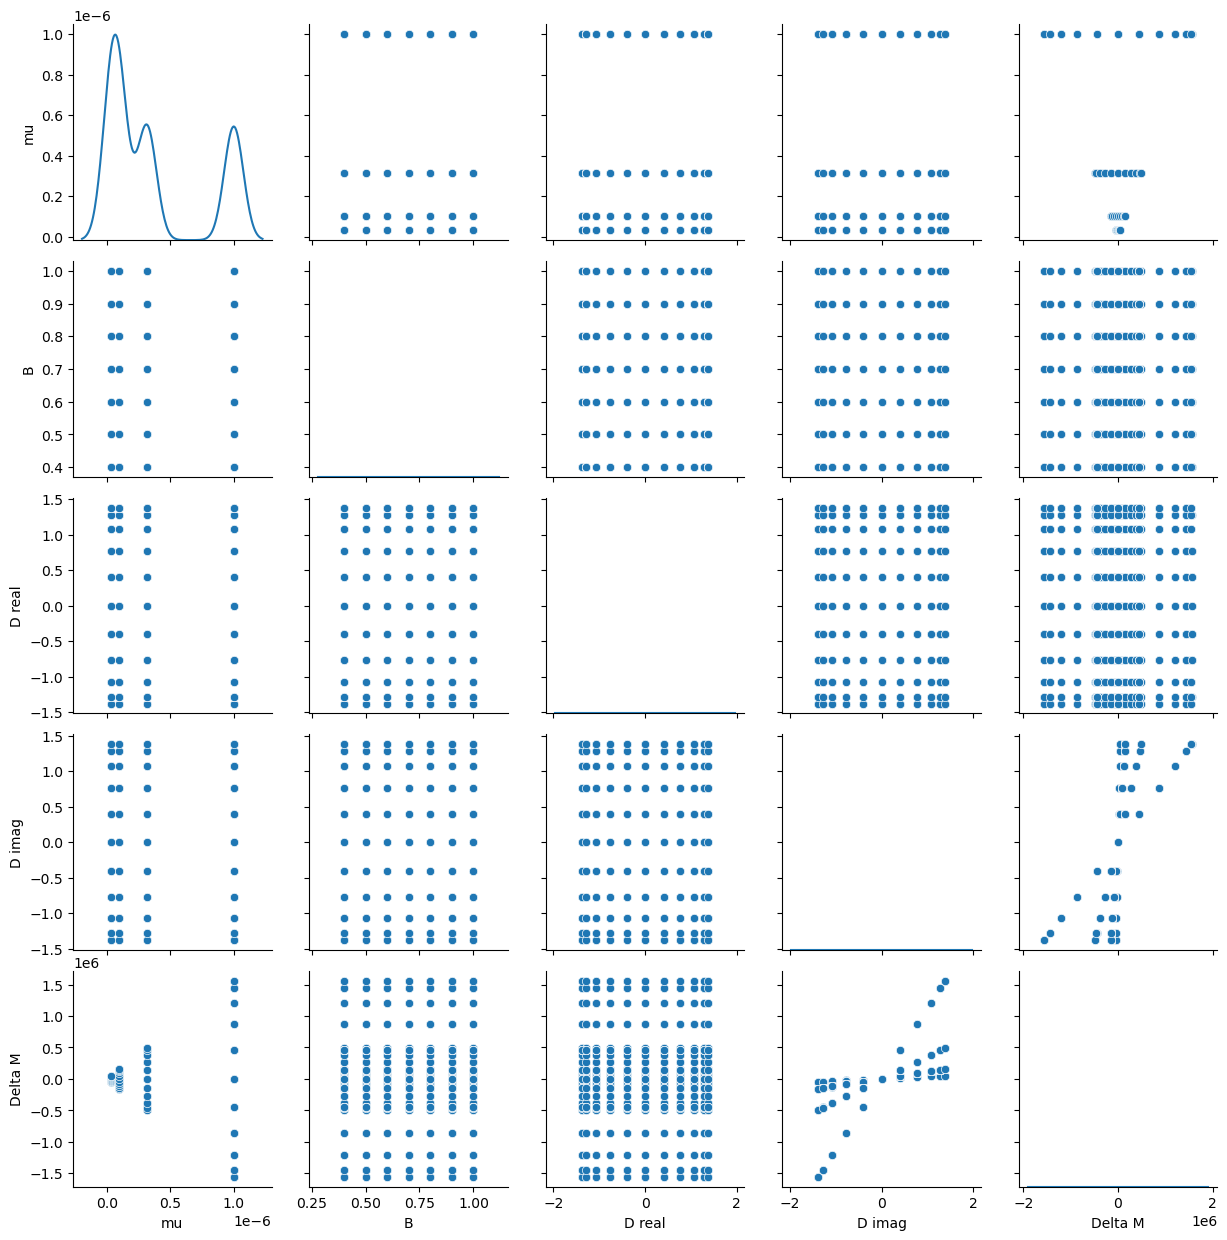

In [15]:
g = sns.PairGrid(dfa)

g.map_diag(sns.kdeplot)
g.map_upper(sns.scatterplot)
g.map_lower(sns.scatterplot)

After removing the erroneous points, I can see clear linear dependence here. Delta M here designated $M_{\mu} - M_0$ where $M_{\mu}$ is the new modeled slow wave number and $M_0$ is the slow wave number for the linear model.

# $\mu$ linear regression fitting

Linear regression will proceed as in the fast oscillation $k$ modelling. I will fit $\mu^2$, $\mu$, and the intercept terms. It will be seen that I only need a $\mu$ term, as we don't need to be so precise with the data as for the fast oscillation modeling.

In [27]:
slope = np.zeros((n_bf, n_g, n_g))
intercept = np.zeros((n_bf, n_g, n_g))
r_save = np.zeros((n_bf, n_g, n_g))
r = 1.1    # for finding the minimum r value

for j, jj in enumerate(B_gf):
    for k1, kk1 in enumerate(dgridk0):
        for k2, kk2 in enumerate(dgridk0):
            df_mu_sel = dfa[(dfa['B'] == jj) & (dfa['D real'] == kk1)&(dfa['D imag'] == kk2)]

            x = df_mu_sel['mu'].to_numpy()
            X = np.array(x, ndmin = 2).T
            y = df_mu_sel['Delta M'].to_numpy()

            reg = LinearRegression().fit(X, y)

            slope[j,k1, k2]=reg.coef_[0]
            intercept[j,k1, k2]=reg.intercept_
            r_save[j,k1,k2]= reg.score(X, y)

            r2 = reg.score(X, y)
            r = min(r, r2)

            if r2 < 0.98: print(j,k1,k2,kk1, slope[j,k1, k2], intercept[j,k1,k2], r2)

print(r)

0.9999983238179493


The fit is good for all of the cases.

In [35]:
slope = np.zeros((n_bf, n_g, n_g))
intercept = np.zeros((n_bf, n_g, n_g))
r_save = np.zeros((n_bf, n_g, n_g))
r = 1.1    # for finding the minimum r value

for j, jj in enumerate(B_gf):
    for k1, kk1 in enumerate(dgridk0):
        for k2, kk2 in enumerate(dgridk0):
            df_mu_sel = dfa[(dfa['B'] == jj) & (dfa['D real'] == kk1)&(dfa['D imag'] == kk2)]

            x = df_mu_sel['mu'].to_numpy()
            X = np.array(x, ndmin = 2).T
            y = df_mu_sel['Delta M'].to_numpy()

            reg = LinearRegression(fit_intercept=False).fit(X, y)

            slope[j,k1, k2]=reg.coef_[0]
            intercept[j,k1, k2]=reg.intercept_
            r_save[j,k1,k2]= reg.score(X, y)

            r2 = reg.score(X, y)
            r = min(r, r2)

            if r2 < 0.98: print(j,k1,k2,kk1, slope[j,k1, k2], intercept[j,k1,k2], r2)

print(r)

0.9999889966619746


Only slightly worse. I will use this version which doesn't fit an intercept, as this is what I expect.

Our regression with the new data is worse than that of the old data. I don't know why, but the data may not be exactly the same. 

In [36]:
print("Number of slopes:", slope.shape)

Number of slopes: (7, 11, 11)


In [37]:
npaf_mu = np.zeros(((n_bf)*(n_gf)*(n_g), 4))
sz = [(n_b+n_b-1)*(n_g-1)*(n_g), (n_gf)*(n_g), n_gf, 1]
print(f"Check that our array is the correct size:\n{n_g*(n_gf)*(n_bf)}\n{npaf_mu.shape}")

Check that our array is the correct size:
770
(770, 4)


The size here should be 770, which is 7 * 10 * 11, as one of our two derivative parameters has lost a grid point due to error.

In [41]:
# This is intended for use with pandas.
# Columns are parameter / variable values here.

for ib in range(n_bf):
    for idr in range(n_g):
        for idi in range(n_gf):
            ind = ib*sz[1]+idr*sz[2]+idi
            #print(ib, idr, idi, ind)
            npaf_mu[ind, 0] = B_gf[ib]
            idr2 = idr
            idi2 = idi
            #if idr > 4: idr2+=1
            if idi > 4: idi2+=1
            npaf_mu[ind, 1] = np.real(dgridk[idr2, idi2])
            npaf_mu[ind, 2] = np.imag(dgridk[idr2, idi2])
            #npaf_mu[ind, 1] = np.real(dgridk[idi2, idr2])
            #npaf_mu[ind, 2] = np.imag(dgridk[idi2, idr2])
            npaf_mu[ind, 3] = slope[ib, idr2, idi2] #* B_gf[ib]


In [42]:
# now as a pandas dataframe
dfa_mu = pd.DataFrame(npaf_mu, columns = ["B", "D real", "D imag", "slope"])

# and to show it
dfa_mu

,B,D real,D imag,slope
0,0.4,-1.380781,-1.380781,-1.556993e+12
1,0.4,-1.380781,-1.281304,-1.444127e+12
2,0.4,-1.380781,-1.071753,-1.208503e+12
3,0.4,-1.380781,-0.770130,-8.687119e+11
4,0.4,-1.380781,-0.402347,-4.544755e+11
...,...,...,...,...
765,1.0,1.380781,0.402347,4.508330e+11
766,1.0,1.380781,0.770130,8.652148e+11
767,1.0,1.380781,1.071753,1.204275e+12
768,1.0,1.380781,1.281304,1.440392e+12


# Visualization

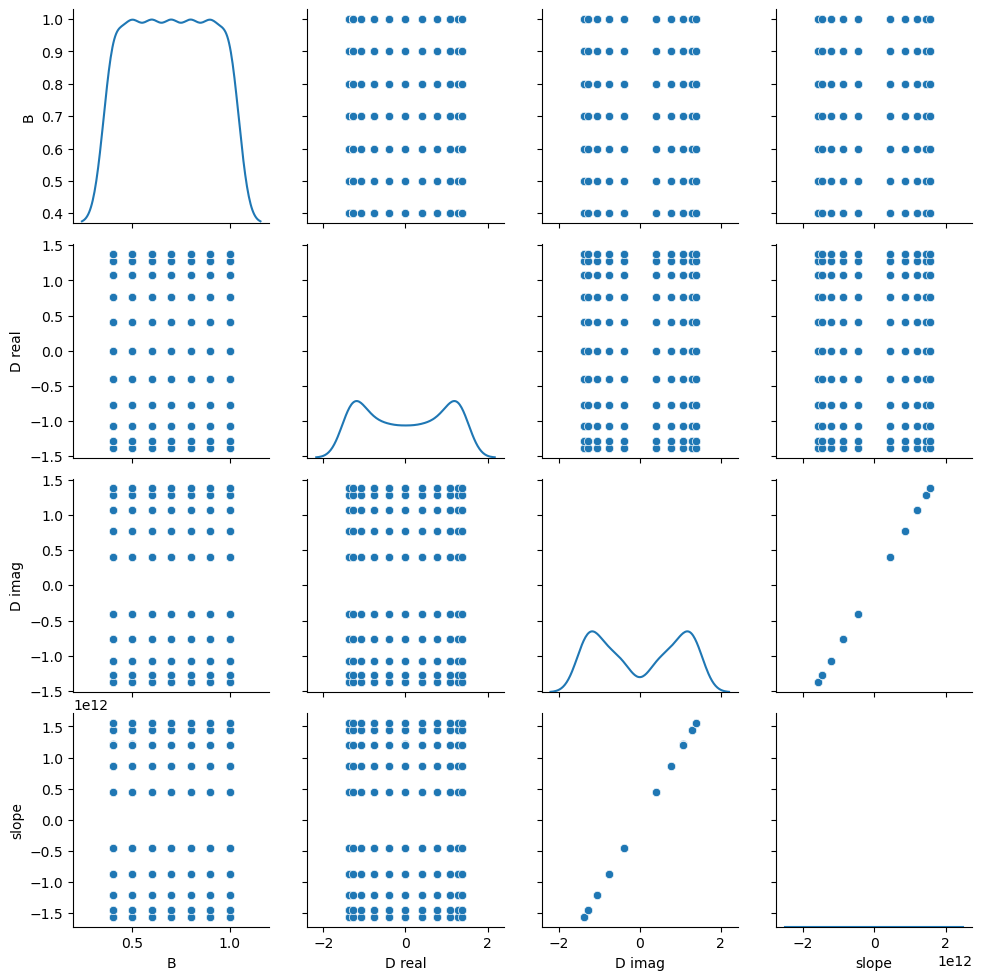

In [43]:
g = sns.PairGrid(dfa_mu)

g.map_diag(sns.kdeplot)
g.map_upper(sns.scatterplot)
g.map_lower(sns.scatterplot)

Linear dependence visible here.

# $\psi^\prime_0$ Regression

This is the regression for $\mathrm{Im}(\psi_0^\prime)$

In [44]:
slope2 = np.zeros((n_bf, n_g))
intercept2 = np.zeros((n_bf, n_g))
r_save = np.zeros((n_bf, n_g))
r = 1.1    # for finding the minimum r value

k1 = 1

for j, jj in enumerate(B_gf):
    for k2, kk2 in enumerate(dgridk0):
        if k1 != 5 and k2 !=5:
            df_psi_sel = dfa_mu[(dfa_mu['B'] == jj)&(dfa_mu['D real'] == kk2)]

            x = df_psi_sel['D imag'].to_numpy()
            X = np.array(x, ndmin = 2).T
            y = df_psi_sel['slope'].to_numpy()

            reg = LinearRegression(fit_intercept=False).fit(X, y)

            slope2[j, k2]=reg.coef_[0]
            intercept2[j, k2]=reg.intercept_
            r_save[j,k2]= reg.score(X, y)

            r2 = reg.score(X, y)
            r = min(r, r2)

print(r)

0.999996740229334


Great success!!!

In [45]:
np.shape(slope2)

(7, 11)

Now to take the average of this dataset, in order to find the one term model, assuming no dependence on other parameters. This number has been saved  in const_dic_003 as "mdI". For the new dataset, the constant has not been saved. The difference is sufficiently small when compared to our results.

In [46]:
full_ave = (np.average(slope2[:,:5])+np.average(slope2[:,6:]))/2
print("Average:", full_ave)
print("Percent std left: ", np.std(slope2[:,:5])/full_ave)
print("Percent std right:", np.std(slope2[:,6:])/full_ave)

Average: 1126214570932.732
Percent std left:  0.0005449644346391447
Percent std right: 0.0005405402309765848


70 slopes have been found. Lets make a new table.

In [47]:
npaf_pi = np.zeros(((n_bf)*(n_gf), 3))
sz = [(n_bf)*(n_gf), n_gf, 1]

In [48]:
# This is intended for use with pandas
# Columns are parameter / variable values here

for ib in range(n_bf):
    for idi in range(n_gf):
        ind = ib*sz[1]+idi
        
        npaf_pi[ind, 0] = B_gf[ib]
        idi2 = idi
        if idi > 4: idi2+=1
        npaf_pi[ind, 1] = dgridk0[idi2]
        npaf_pi[ind, 2] = slope2[ib, idi2]

In [49]:
# now as a pandas dataframe
dfa_pi = pd.DataFrame(npaf_pi, columns = ["B", "D real", "slope"])

# and to show it
dfa_pi

,B,D real,slope
0,0.4,-1.380781,1.126374e+12
1,0.4,-1.281304,1.126472e+12
2,0.4,-1.071753,1.126251e+12
3,0.4,-0.770130,1.126685e+12
4,0.4,-0.402347,1.127715e+12
...,...,...,...
65,1.0,0.402347,1.126378e+12
66,1.0,0.770130,1.125875e+12
67,1.0,1.071753,1.125520e+12
68,1.0,1.281304,1.125814e+12


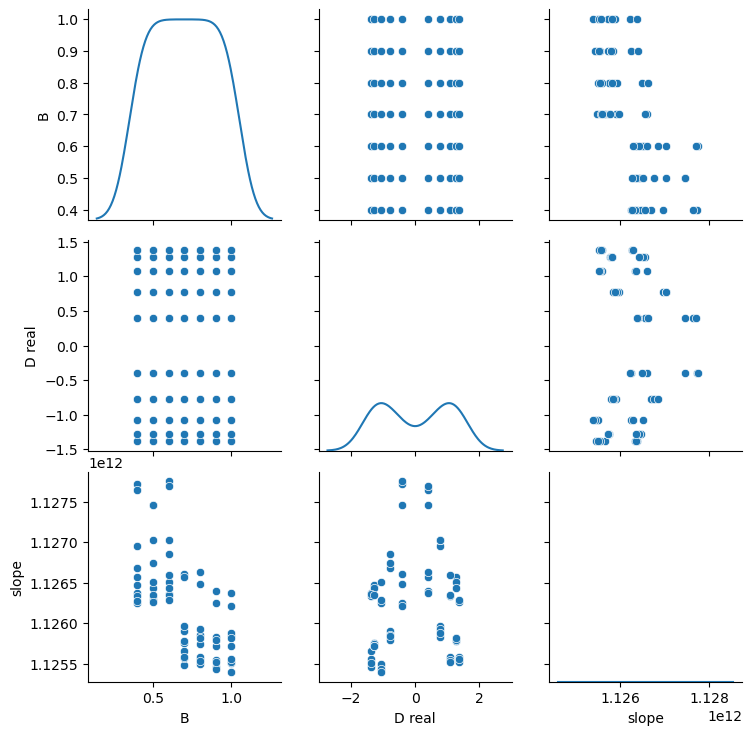

In [50]:
g = sns.PairGrid(dfa_pi)

g.map_diag(sns.kdeplot)
g.map_upper(sns.scatterplot)
g.map_lower(sns.scatterplot)

I don't know how much of the remaining variation is real. $B$ dependence appears chaotic, $\mathrm{Re} (\psi_0^\prime)$ dependence appears to have a retrievable quadratic dependence, but it is unlikely to be needed. 

The new analysis shows a term linear in the absolute value of $\mathrm{Re} (\psi_0^\prime)$.

# $k$ and $M$ Regression for $\mu$ Linear Term

In [51]:
dfa_pi

,B,D real,slope
0,0.4,-1.380781,1.126374e+12
1,0.4,-1.281304,1.126472e+12
2,0.4,-1.071753,1.126251e+12
3,0.4,-0.770130,1.126685e+12
4,0.4,-0.402347,1.127715e+12
...,...,...,...
65,1.0,0.402347,1.126378e+12
66,1.0,0.770130,1.125875e+12
67,1.0,1.071753,1.125520e+12
68,1.0,1.281304,1.125814e+12


In [52]:
slope3 = np.zeros((n_bf))
intercept3 = np.zeros(n_bf)
r_save = np.zeros(n_bf)
r = 1.1    # for finding the minimum r value

for j, jj in enumerate(B_gf):
#for k1, kk1 in enumerate(np.real(dgrid[0]/(gridl_2.l_calc.k))):
    #for k2, kk2 in enumerate(np.real(dgrid[0]/(gridl_1.l_calc.k))):
        #if k1 != 5 and k2 !=5:
            df_B_sel = dfa_pi[(dfa_pi['B'] == jj)]

            x = np.array([np.power(df_B_sel['D real'].to_numpy(), 2)])#.T
            X = np.array(x).T
            y = df_B_sel['slope'].to_numpy()

            reg = LinearRegression().fit(X, y)

            slope3[j]=reg.coef_[0]
            intercept3[j]=reg.intercept_
            r_save[j]= reg.score(X, y)

            r2 = reg.score(X, y)
            r = min(r, r2)

            if r2 < 0.99: print(j, slope3[j], intercept3[j], r2)

print(r)

0 -672043781.0850109 1127458783422.556 0.704423316193812
1 -609157187.0551006 1127350224072.1465 0.7824525802655298
2 -747482802.1545452 1127599209729.3352 0.8677410579815538
3 -467028284.28805465 1126395368421.57 0.642782306838636
4 -473268776.01295227 1126379299008.9998 0.659397455094812
5 -379292636.5592058 1126188255912.4094 0.6258380555850218
6 -357884832.7384874 1126172000586.8135 0.5918197891018377
0.5918197891018377


In [53]:
slope4 = np.zeros((n_bf,2))
intercept4 = np.zeros(n_bf)
r_save = np.zeros(n_bf)
r = 1.1    # for finding the minimum r value

for j, jj in enumerate(B_gf):
#for k1, kk1 in enumerate(np.real(dgrid[0]/(gridl_2.l_calc.k))):
    #for k2, kk2 in enumerate(np.real(dgrid[0]/(gridl_1.l_calc.k))):
        #if k1 != 5 and k2 !=5:
            df_B_sel = dfa_pi[(dfa_pi['B'] == jj)]

            x = np.array([np.power(df_B_sel['D real'].to_numpy(), 2), np.power(np.abs(df_B_sel['D real'].to_numpy()), 1)])#.T
            X = np.array(x).T
            y = df_B_sel['slope'].to_numpy()

            reg = LinearRegression().fit(X, y)

            slope4[j]=reg.coef_[0]
            intercept4[j]=reg.intercept_
            r_save[j]= reg.score(X, y)

            r2 = reg.score(X, y)
            r = min(r, r2)

            if r2 < 0.99: print(j, slope4[j], intercept4[j], r2)

print(r)

0 [1.9168653e+09 1.9168653e+09] 1129280393502.3281 0.9458511596943997
1 [1.13643315e+09 1.13643315e+09] 1128578457604.9963 0.9308406914013116
3 [1.64139041e+09 1.64139041e+09] 1127878895506.9856 0.9453387677377924
4 [1.48515447e+09 1.48515447e+09] 1127757286184.8462 0.9201687821848877
5 [1.1354031e+09 1.1354031e+09] 1127254027221.1736 0.8563424016679411
6 [1.13357945e+09 1.13357945e+09] 1127221425759.0469 0.8291995976429469
0.8291995976429469


In the old analysis, the quadratic term for $\mathrm{Re}\left(\psi^\prime_0\right)$ was a better fit than both these terms together for the new run. The linear term didn't help at all for the old fit. Here I have two terms. I have kept my old statistics, so as to not rerun the models, as the difference is within my tolerance. 

In [50]:
print(intercept3[4], np.average(intercept3))
print(intercept4[4], np.average(intercept4))
print(slope3[4], np.average(slope3))
print(slope4[4], np.average(slope4, axis=0))

1114237499154.8862 1114503328463.9722
1114237499154.8862 1114503328463.9722
1570409024.3666248 1487350163.9047058
[1.57040902e+09 5.78521435e+06] [1.48735016e+09 8.42335915e+06]


In [ ]:
print("Slope with linear term relative std:        ", np.std(slope4, axis=0) / np.average(slope4, axis=0))
print("Intercept without linear term relative std: ", np.std(intercept3) / np.average(intercept3))
print("Slope without linear term relative std:     ", np.std(slope3) / np.average(slope3))

Slope with linear term relative std:         [0.16510184 0.47860923]
Intercept withour linear term relative std:  0.0004616326145078832
Slope withour linear term relative std:      0.1651018353627821


# Model Testing

This tests the model for the grids. I use my saved model from my library for this, rather than trying to recreate it here. 

In [54]:
# Here we are changing the format of variable storage
# This is intended for use with pandas
# Columns are parameter / variable values here

size1 = np.shape(fot.flatten())[0] * 4 // 5
size2 = np.shape(fot2.flatten())[0]

print(size1+size2)
npaf = np.zeros((size1+size2, 5))

sz1 = [n_b*n_g**2, n_g **2, n_g, 1]
sz2 = [3*n_g**2, n_g **2, n_g, 1]

for imu in range(n_m2):
        for ib in range(n_b):
            for idr in range(n_g):
                for idi in range(n_g):
                    ind = imu*sz1[0]+ib*sz1[1]+idr*sz1[2]+idi
                    #npaf[ind, 0] = mfp[im]
                    #npaf[ind, 1] = ew[ik]
                    npaf[ind, 0] = mu_g[imu]
                    npaf[ind, 1] = B_g[ib]
                    npaf[ind, 2] = np.real(dgrid[idr, idi]) / (gridl_1.l_calc.k)
                    npaf[ind, 3] = np.imag(dgrid[idr, idi]) / (gridl_1.l_calc.k)
                    npaf[ind, 4] = fot[imu, ib, idr, idi] - pred_slow_k_v2(dgrid[idr, idi], mu_g[imu], 0., B_g[ib] * B_max, R_max, k0 = gridl_1.l_calc.k)
                    #npaf[ind, 5] = fot[imu, ib, idr, idi]
                    if np.abs(npaf[ind, 3]) < 1.0e-6: npaf[ind,4] = np.nan # removes erroneous points
                    if np.abs(npaf[ind, 2]) < 1.0e-6: npaf[ind,4] = np.nan # removes erroneous points


for imu in range(n_m2):
        for ib in range(n_b2):
            for idr in range(n_g):
                for idi in range(n_g):
                    ind = size1+imu*sz2[0]+ib*sz2[1]+idr*sz2[2]+idi
                    #npaf[ind, 0] = mfp[im]
                    #npaf[ind, 1] = ew[ik]
                    npaf[ind, 0] = mu_g2[imu]
                    npaf[ind, 1] = B_g2[ib]
                    npaf[ind, 2] = np.real(dgrid2[idr, idi]) / (gridl_2.l_calc.k)
                    npaf[ind, 3] = np.imag(dgrid2[idr, idi]) / (gridl_2.l_calc.k)
                    npaf[ind, 4] = fot2[imu, ib, idr, idi] - pred_slow_k_v2(dgrid2[idr, idi], mu_g2[imu], 0., B_g2[ib] * B_max, R_max, k0 = gridl_2.l_calc.k)
                    #npaf[ind, 5] = fot2[imu, ib, idr, idi]
                    if np.abs(npaf[ind, 3]) < 1.0e-6: npaf[ind,4] = np.nan # removes erroneous points
                    if np.abs(npaf[ind, 2]) < 1.0e-6: npaf[ind,4] = np.nan # removes erroneous points

3388


In [55]:
# now as a pandas dataframe
dfa = pd.DataFrame(npaf, columns = ["mu", "B", "D real", "D imag", "delta M new"])

# and to show it
dfa

,mu,B,D real,D imag,delta M new
0,3.162278e-08,0.7,-1.380781,-1.380781,-403.342499
1,3.162278e-08,0.7,-1.380781,-1.281304,-180.917571
2,3.162278e-08,0.7,-1.380781,-1.071753,-283.707880
3,3.162278e-08,0.7,-1.380781,-0.770130,-430.653956
4,3.162278e-08,0.7,-1.380781,-0.402347,-203.748069
...,...,...,...,...,...
3383,1.000000e-06,0.6,1.380781,0.402347,2075.349938
3384,1.000000e-06,0.6,1.380781,0.770130,6212.786641
3385,1.000000e-06,0.6,1.380781,1.071753,8755.956381
3386,1.000000e-06,0.6,1.380781,1.281304,11208.043244


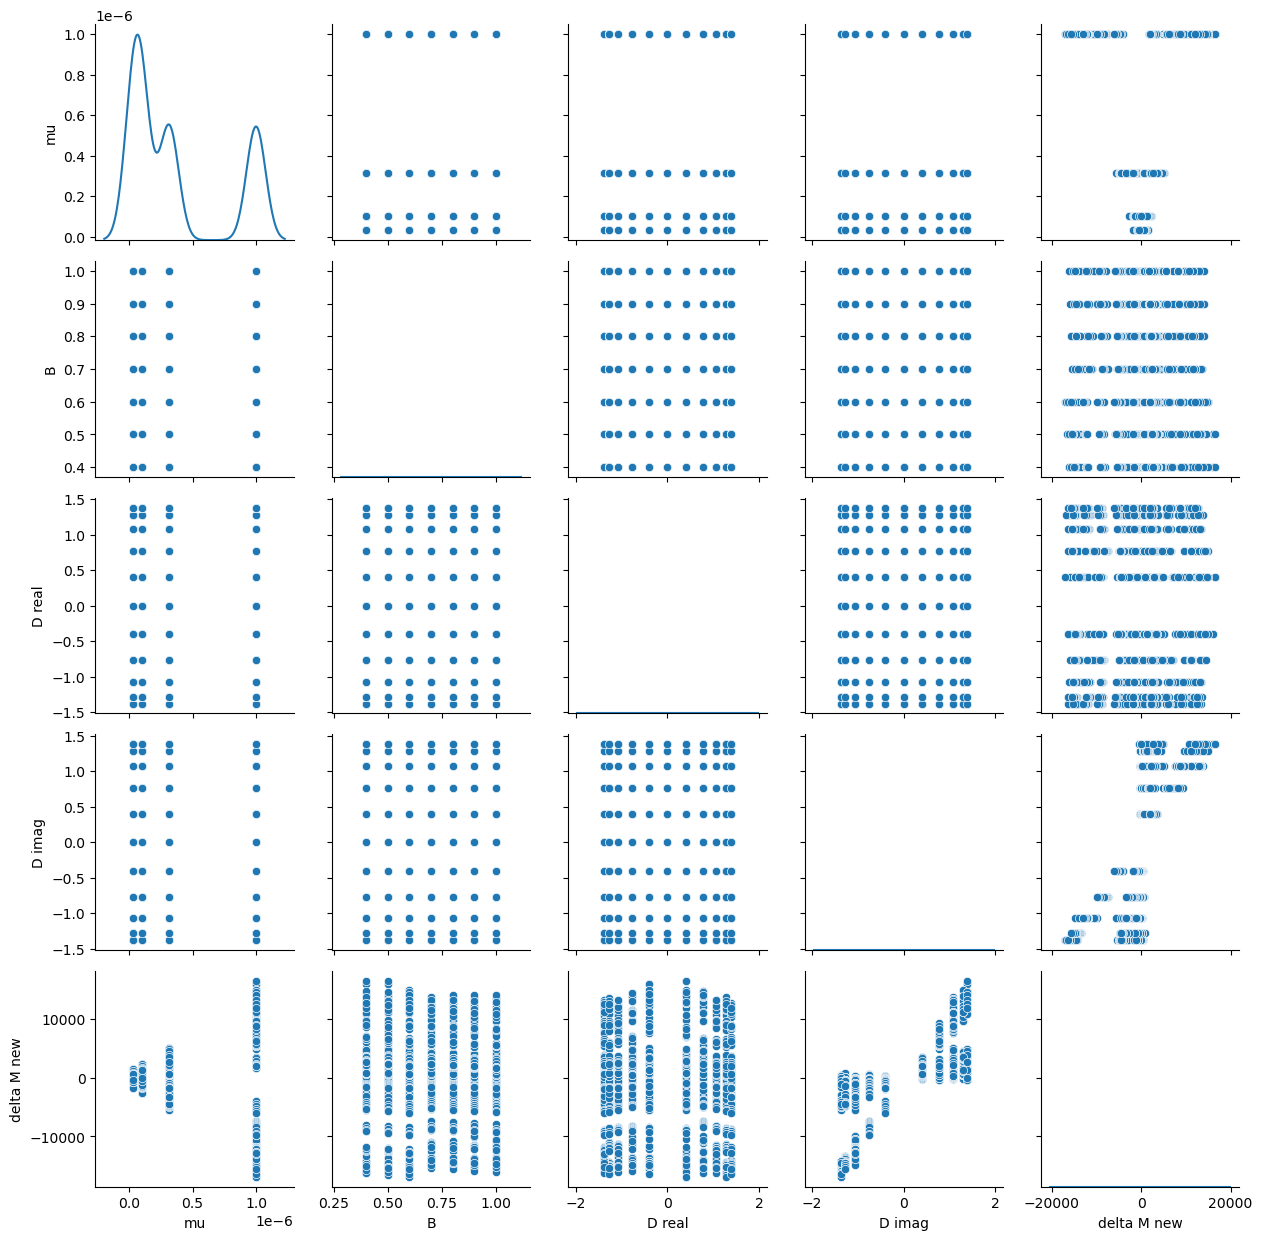

In [56]:
g = sns.PairGrid(dfa)

g.map_diag(sns.kdeplot)
g.map_upper(sns.scatterplot)
g.map_lower(sns.scatterplot)

In [57]:
print("Estimate for maximum error:", np.nanmax(dfa["delta M new"].to_numpy()) / np.min(np.abs(fot[imu, ib, idr, idi])))

Estimate for maximum error: 0.0015831693046329603


In [58]:
# Here we are changing the format of variable storage
# This is intended for use with pandas
# Columns are parameter / variable values here

size1 = np.shape(fot.flatten())[0] * 4 // 5
size2 = np.shape(fot2.flatten())[0]

print(size1+size2)
npaf = np.zeros((size1+size2, 5))

sz1 = [n_b*n_g**2, n_g **2, n_g, 1]
sz2 = [3*n_g**2, n_g **2, n_g, 1]

for imu in range(n_m2):
        for ib in range(n_b):
            for idr in range(n_g):
                for idi in range(n_g):
                    ind = imu*sz1[0]+ib*sz1[1]+idr*sz1[2]+idi
                    #npaf[ind, 0] = mfp[im]
                    #npaf[ind, 1] = ew[ik]
                    npaf[ind, 0] = mu_g[imu]
                    npaf[ind, 1] = B_g[ib]
                    npaf[ind, 2] = np.real(dgrid[idr, idi]) / (gridl_1.l_calc.k)
                    npaf[ind, 3] = np.imag(dgrid[idr, idi]) / (gridl_1.l_calc.k)
                    npaf[ind, 4] = fot[imu, ib, idr, idi] - pred_slow_k_v3(dgrid[idr, idi], mu_g[imu], 0., B_g[ib] * B_max, R_max, k0 = gridl_1.l_calc.k)
                    if np.abs(npaf[ind, 3]) < 1.0e-6: npaf[ind,4] = np.nan # removes erroneous points
                    if np.abs(npaf[ind, 2]) < 1.0e-6: npaf[ind,4] = np.nan # removes erroneous points


for imu in range(n_m2):
        for ib in range(n_b2):
            for idr in range(n_g):
                for idi in range(n_g):
                    ind = size1+imu*sz2[0]+ib*sz2[1]+idr*sz2[2]+idi
                    #npaf[ind, 0] = mfp[im]
                    #npaf[ind, 1] = ew[ik]
                    npaf[ind, 0] = mu_g2[imu]
                    npaf[ind, 1] = B_g2[ib]
                    npaf[ind, 2] = np.real(dgrid2[idr, idi]) / (gridl_2.l_calc.k)
                    npaf[ind, 3] = np.imag(dgrid2[idr, idi]) / (gridl_2.l_calc.k)
                    npaf[ind, 4] = fot2[imu, ib, idr, idi] - pred_slow_k_v3(dgrid2[idr, idi], mu_g2[imu], 0., B_g2[ib] * B_max, R_max, k0 = gridl_2.l_calc.k)
                    if np.abs(npaf[ind, 3]) < 1.0e-6: npaf[ind,4] = np.nan # removes erroneous points
                    if np.abs(npaf[ind, 2]) < 1.0e-6: npaf[ind,4] = np.nan # removes erroneous points

3388


In [59]:
# now as a pandas dataframe
dfa = pd.DataFrame(npaf, columns = ["mu", "B", "D real", "D imag", "delta M new"])

# and to show it
dfa

,mu,B,D real,D imag,delta M new
0,3.162278e-08,0.7,-1.380781,-1.380781,-350.337285
1,3.162278e-08,0.7,-1.380781,-1.281304,-131.731082
2,3.162278e-08,0.7,-1.380781,-1.071753,-242.565605
3,3.162278e-08,0.7,-1.380781,-0.770130,-401.090326
4,3.162278e-08,0.7,-1.380781,-0.402347,-188.302823
...,...,...,...,...,...
3383,1.000000e-06,0.6,1.380781,0.402347,1586.928367
3384,1.000000e-06,0.6,1.380781,0.770130,5277.902587
3385,1.000000e-06,0.6,1.380781,1.071753,7454.923415
3386,1.000000e-06,0.6,1.380781,1.281304,9652.629883


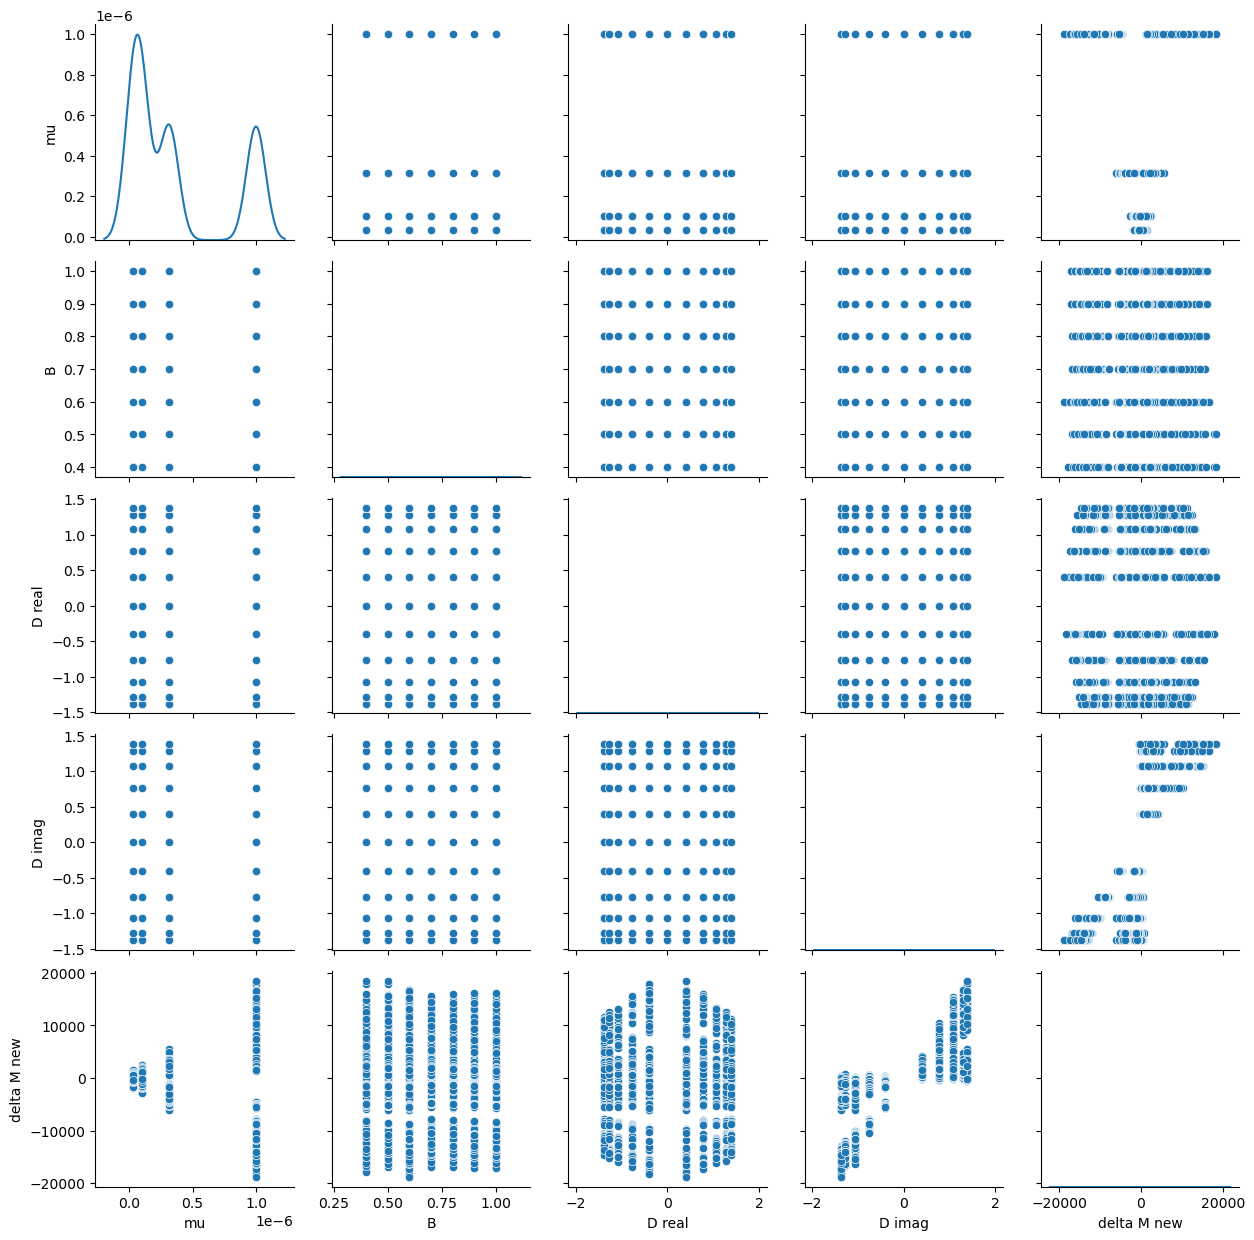

In [60]:
g = sns.PairGrid(dfa)

g.map_diag(sns.kdeplot)
g.map_upper(sns.scatterplot)
g.map_lower(sns.scatterplot)


I see an absolute value of the derivative term here. Dependence on $\mu$ is still linear. $B$ does something, but I don't know what. There is also a linear imaginary term and a linear absolute value real term.

In [61]:
print("Estimate for maximum error:", np.nanmax(dfa["delta M new"].to_numpy()) / np.min(np.abs(fot[imu, ib, idr, idi])))

Estimate for maximum error: 0.0017658225138741375


The results are not as good as the results from the previous run, which is to be expected, as I am no longer fitting to the same dataset I trained the model on. I could in theory get more terms, but I don't need them.